In [2]:
# ── Core Libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── ML Libraries ────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)

# ── Deep Learning ────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print("All libraries loaded ✅")

TensorFlow version: 2.21.0
All libraries loaded ✅


In [3]:
# Dataset load karo
df = pd.read_csv('../data/bugs.csv')

print("Shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Shape: (100000, 36)

First 3 rows:


,bug_id,bug_type,component,environment,platform,operating_system,browser,reporter_role,module,status,...,api_call_count,db_query_time_ms,is_regression,is_security_related,has_workaround,customer_reported,sla_breached,created_at,resolved_at,severity
0,BUG-000001,UncaughtException,EmailService,Development,iOS,Windows10,Edge,End_User,Integration,Resolved,...,60,1290,0,0,1,0,0,2022-04-09,2022-04-18,Low
1,BUG-000002,XSS,Analytics,QA,Desktop,Ubuntu20,Safari,Client,Core,In_Progress,...,630,635,0,0,0,0,0,2021-04-15,2021-05-02,Low
2,BUG-000003,RaceCondition,SearchEngine,Production,Web,macOS13,Edge,QA_Engineer,Integration,Reopened,...,374,1928,0,0,1,0,1,2022-06-18,2022-07-17,Critical


In [4]:
print("=== Dataset Info ===")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

=== Dataset Info ===
Rows: 100,000  |  Columns: 36


In [5]:
print("\n=== Null Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])


=== Null Values ===
browser    16879
dtype: int64


In [6]:
# Browser ka N/A fill karo
df['browser'] = df['browser'].fillna('N/A')

# Verify
print("Null values after fix:", df.isnull().sum().sum())
print("Browser values:")
print(df['browser'].value_counts())

Null values after fix: 0
Browser values:
browser
Edge          17340
Mobile_App    17328
N/A           16879
Safari        16870
Firefox       15853
Chrome        15730
Name: count, dtype: int64


In [7]:
print("\n=== Data Types ===")
print(df.dtypes.value_counts())


=== Data Types ===
int64      21
str        13
float64     2
Name: count, dtype: int64


In [8]:
print("\n=== Target Class Distribution ===")
print(df['severity'].value_counts())


=== Target Class Distribution ===
severity
Low         25000
Critical    25000
Medium      25000
High        25000
Name: count, dtype: int64


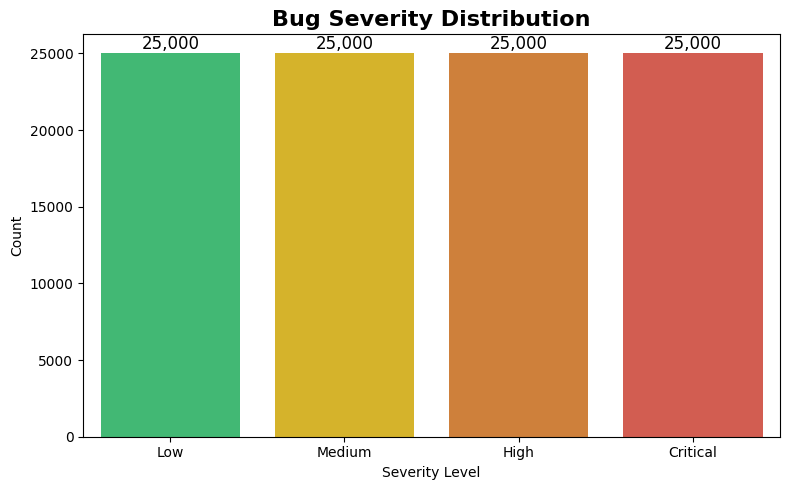

In [9]:
plt.figure(figsize=(8, 5))
order = ['Low', 'Medium', 'High', 'Critical']
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

sns.countplot(data=df, x='severity', order=order, palette=colors)
plt.title('Bug Severity Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Severity Level')
plt.ylabel('Count')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height()):,}',
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

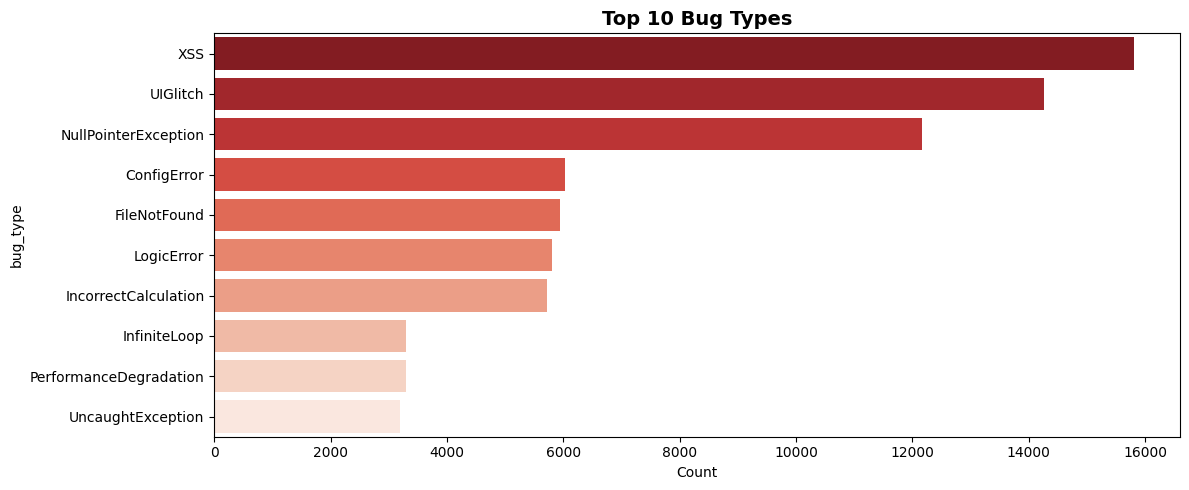

In [10]:
plt.figure(figsize=(12, 5))
top_bugs = df['bug_type'].value_counts().head(10)
sns.barplot(x=top_bugs.values, y=top_bugs.index, palette='Reds_r')
plt.title('Top 10 Bug Types', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

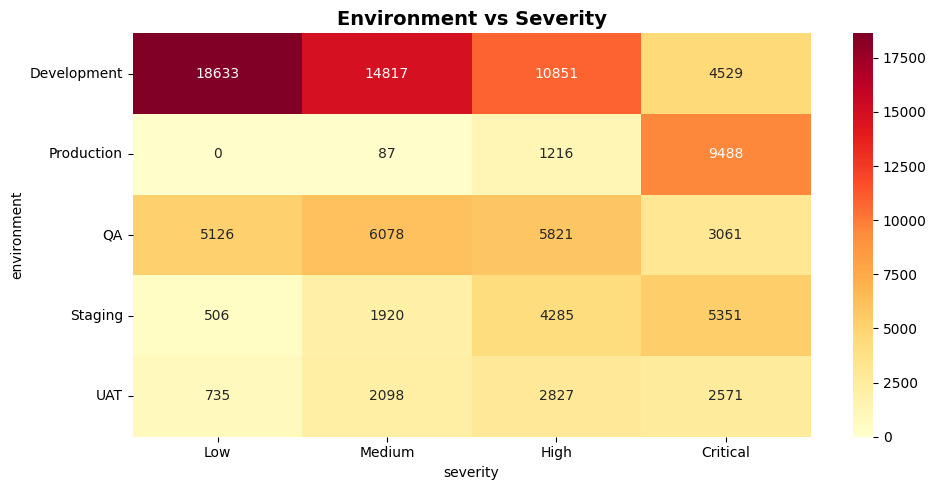

In [11]:
plt.figure(figsize=(10, 5))
pivot = pd.crosstab(df['environment'], df['severity'])
pivot = pivot[['Low', 'Medium', 'High', 'Critical']]
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Environment vs Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

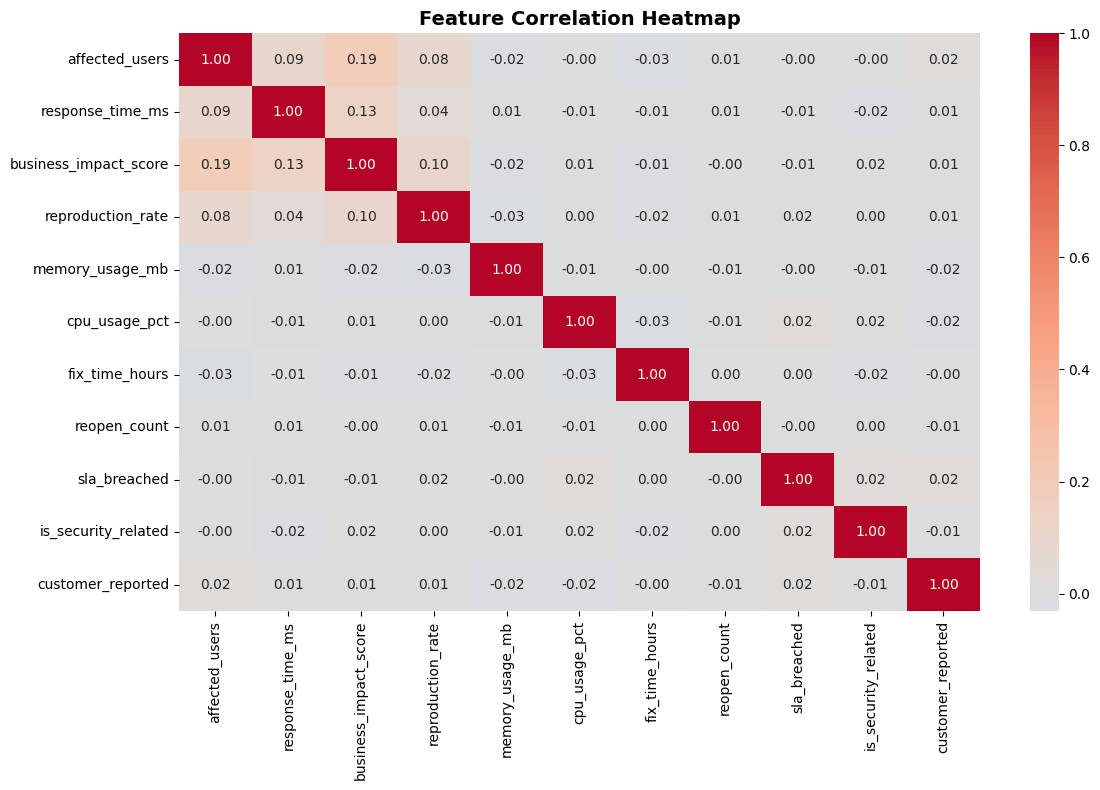

In [12]:
num_cols = ['affected_users', 'response_time_ms', 'business_impact_score',
            'reproduction_rate', 'memory_usage_mb', 'cpu_usage_pct',
            'fix_time_hours', 'reopen_count', 'sla_breached',
            'is_security_related', 'customer_reported']

plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
df_clean = df.drop(columns=['bug_id', 'created_at', 'resolved_at'])

print("Removed: bug_id, created_at, resolved_at")
print("Remaining columns:", df_clean.shape[1])

Removed: bug_id, created_at, resolved_at
Remaining columns: 33


In [14]:

# Label Encode Categorical Columns
import pickle, os

cat_cols = ['bug_type', 'component', 'environment', 'platform',
            'operating_system', 'browser', 'reporter_role', 'module', 'status']

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = le

# Target encode
target_le = LabelEncoder()
df_clean['severity'] = target_le.fit_transform(df_clean['severity'])

print("Severity classes:", target_le.classes_)
# ['Critical'=0, 'High'=1, 'Low'=2, 'Medium'=3]

os.makedirs('../model', exist_ok=True)
with open('../model/label_encoder.pkl', 'wb') as f:
    pickle.dump({'features': encoders, 'target': target_le}, f)

print("Encoders saved ✅")

Severity classes: ['Critical' 'High' 'Low' 'Medium']
Encoders saved ✅


In [15]:
import pickle
with open('../model/label_encoder.pkl', 'rb') as f:
    data = pickle.load(f)

target_le = data['target']
print("Classes:", target_le.classes_)
# 0=?, 1=?, 2=?, 3=?

# Test prediction manually
import numpy as np
print("\nClass mapping:")
for i, cls in enumerate(target_le.classes_):
    print(f"  {i} → {cls}")

Classes: ['Critical' 'High' 'Low' 'Medium']

Class mapping:
  0 → Critical
  1 → High
  2 → Low
  3 → Medium


In [16]:
# Scale + Save Scaler
feature_cols = [c for c in df_clean.columns if c != 'severity']

X = df_clean[feature_cols].values
y = df_clean['severity'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

with open('../model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"X shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")
print("Scaler saved ✅")

X shape: (100000, 32)
y shape: (100000,)
Scaler saved ✅


In [17]:
#Save processed_bugs.csv
df_clean.to_csv('../data/processed_bugs.csv', index=False)
print("processed_bugs.csv saved ✅")
print("Shape:", df_clean.shape)
df_clean.head(3)

processed_bugs.csv saved ✅
Shape: (100000, 33)


,bug_type,component,environment,platform,operating_system,browser,reporter_role,module,status,affected_users,...,reopen_count,num_linked_bugs,api_call_count,db_query_time_ms,is_regression,is_security_related,has_workaround,customer_reported,sla_breached,severity
0,18,6,0,4,3,1,3,1,4,685,...,0,3,60,1290,0,0,1,0,0,2
1,19,1,2,2,2,5,0,0,1,545,...,4,5,630,635,0,0,0,0,0,2
2,15,13,1,3,6,1,5,1,3,2655,...,0,9,374,1928,0,0,1,0,1,0


In [18]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

num_classes = len(target_le.classes_)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Classes:", target_le.classes_)

Train: (80000, 32)
Test: (20000, 32)
Classes: ['Critical' 'High' 'Low' 'Medium']


In [19]:
# ANN Model Build
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,604 (209.39 KB)

 Trainable params: 52,708 (205.89 KB)

 Non-trainable params: 896 (3.50 KB)

In [23]:
# Train + Save
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, 
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, 
                      patience=5, verbose=1)
]

history = model.fit(
    X_train, y_train_cat,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    class_weight={0: 1.0, 1: 1.5, 2: 2.0, 3: 1.5},
    callbacks=callbacks,
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'\nTest Accuracy: {test_acc*100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

# Save
model.save('../model/model.keras')
print('\nModel saved! ✅')

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8648 - loss: 0.4182 - val_accuracy: 0.8745 - val_loss: 0.2990 - learning_rate: 2.5000e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8640 - loss: 0.4219 - val_accuracy: 0.8763 - val_loss: 0.2957 - learning_rate: 2.5000e-04
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8661 - loss: 0.4167 - val_accuracy: 0.8770 - val_loss: 0.2949 - learning_rate: 2.5000e-04
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8656 - loss: 0.4149 - val_accuracy: 0.8777 - val_loss: 0.2928 - learning_rate: 2.5000e-04
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8664 - loss: 0.4139 - val_accuracy: 0.8771 - val_loss: 0.2951 - learning_rate: 2.5000e-04
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8653 - loss: 0.4159 - val_accuracy: 0.8771 - val_loss: 0.2940 - learning_rate: 2.5000e-04
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/st

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Classification Report:
              precision    recall  f1-score   support

    Critical       0.92      0.78      0.84      5000
        High       0.76      0.78      0.77      5000
         Low       1.00      1.00      1.00      5000
      Medium       0.86      0.97      0.91      5000

    accuracy                           0.88     20000
   macro avg       0.88      0.88      0.88     20000
weighted avg       0.88      0.88      0.88     20000



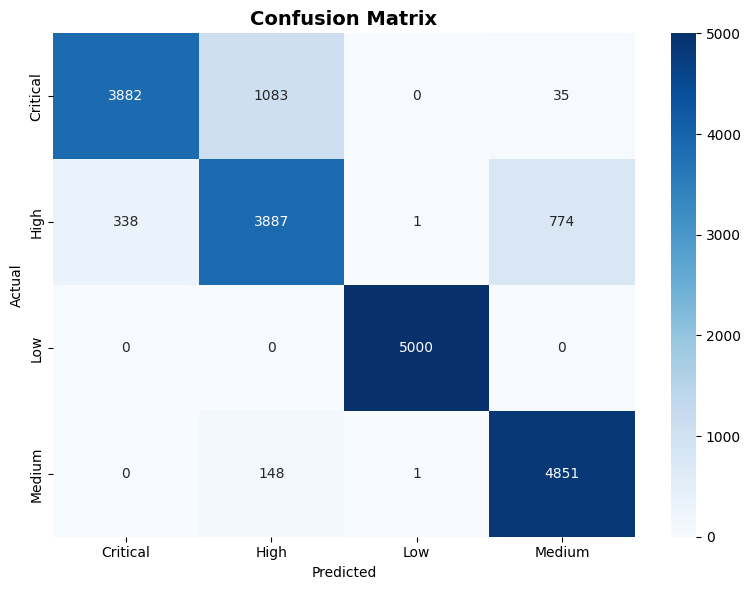

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=target_le.classes_))

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_le.classes_,
            yticklabels=target_le.classes_)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../docs/confusion_matrix.png', dpi=150)
plt.show()

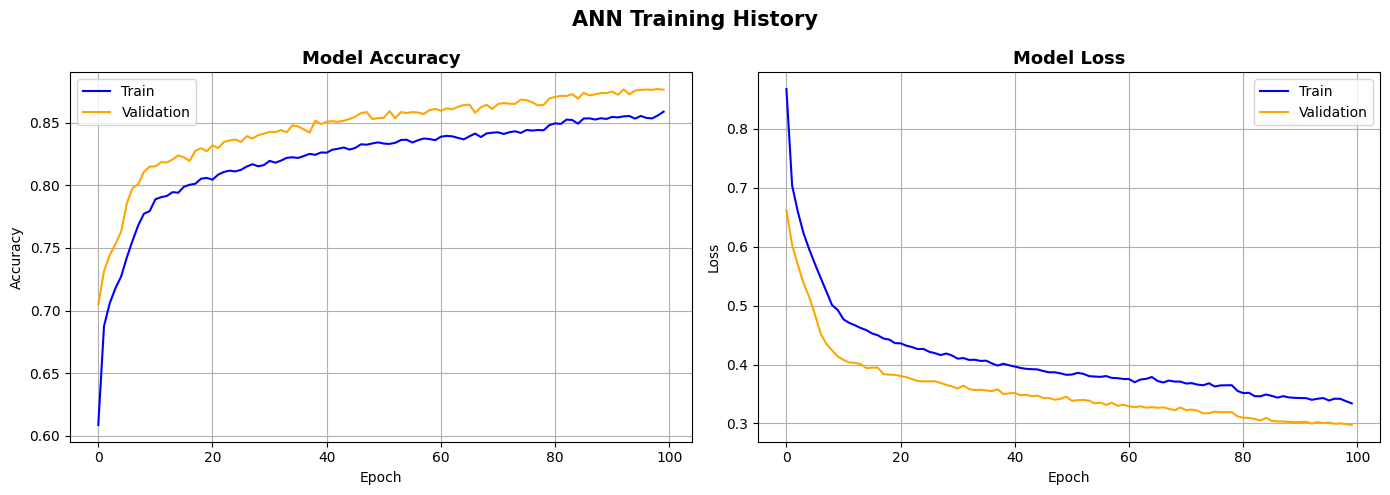

In [22]:
# Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='orange')
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train', color='blue')
axes[1].plot(history.history['val_loss'], label='Validation', color='orange')
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('ANN Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/training_history.png', dpi=150)
plt.show()

In [25]:
# Dataset ka severity distribution check karo
import pandas as pd
df = pd.read_csv('../data/bugs.csv')
print("Original distribution:")
print(df['severity'].value_counts())

# processed check karo
df2 = pd.read_csv('../data/processed_bugs.csv')
print("\nProcessed distribution:")
print(df2['severity'].value_counts())

# Training data mein kya tha
print("\nY train distribution:")
import numpy as np
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

Original distribution:
severity
Low         25000
Critical    25000
Medium      25000
High        25000
Name: count, dtype: int64

Processed distribution:
severity
2    25000
0    25000
3    25000
1    25000
Name: count, dtype: int64

Y train distribution:
{np.int64(0): np.int64(20000), np.int64(1): np.int64(20000), np.int64(2): np.int64(20000), np.int64(3): np.int64(20000)}


In [26]:
# Direct model test karo
import numpy as np
import pickle

# Load artifacts
with open('../model/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('../model/label_encoder.pkl', 'rb') as f:
    enc_data = pickle.load(f)

encoders = enc_data['features']
target_le = enc_data['target']

# LOW severity wala test case
test = {
    'bug_type': 'UIGlitch',
    'component': 'Frontend',
    'environment': 'Development',
    'platform': 'Web',
    'operating_system': 'Windows10',
    'browser': 'Chrome',
    'reporter_role': 'Developer',
    'module': 'Core',
    'status': 'Open',
    'affected_users': 5,
    'response_time_ms': 100,
    'business_impact_score': 1.0,
    'reproduction_rate': 0.1,
    'memory_usage_mb': 100,
    'cpu_usage_pct': 10.0,
    'lines_of_code': 500,
    'open_issues_count': 0,
    'fix_time_hours': 2,
    'num_comments': 0,
    'num_attachments': 0,
    'sprint_number': 1,
    'test_coverage_pct': 50.0,
    'reopen_count': 0,
    'num_linked_bugs': 0,
    'api_call_count': 0,
    'db_query_time_ms': 0,
    'is_regression': 0,
    'is_security_related': 0,
    'has_workaround': 1,
    'customer_reported': 0,
    'sla_breached': 0,
    'error_code': 0
}

FEATURE_ORDER = [
    'bug_type', 'component', 'environment', 'platform',
    'operating_system', 'browser', 'reporter_role', 'module', 'status',
    'affected_users', 'response_time_ms', 'business_impact_score',
    'reproduction_rate', 'memory_usage_mb', 'cpu_usage_pct',
    'lines_of_code', 'open_issues_count', 'fix_time_hours',
    'num_comments', 'num_attachments', 'sprint_number',
    'test_coverage_pct', 'reopen_count', 'num_linked_bugs',
    'api_call_count', 'db_query_time_ms', 'is_regression',
    'is_security_related', 'has_workaround', 'customer_reported',
    'sla_breached', 'error_code'
]

CAT_COLS = ['bug_type', 'component', 'environment', 'platform',
            'operating_system', 'browser', 'reporter_role', 'module', 'status']

row = {}
for feat in FEATURE_ORDER:
    val = test[feat]
    if feat in CAT_COLS:
        le = encoders[feat]
        row[feat] = le.transform([val])[0]
    else:
        row[feat] = float(val)

X = np.array([[row[f] for f in FEATURE_ORDER]])
X_scaled = scaler.transform(X)
probs = model.predict(X_scaled, verbose=0)[0]

print("Probabilities:")
for cls, p in zip(target_le.classes_, probs):
    print(f"  {cls}: {p*100:.2f}%")
print(f"\nPredicted: {target_le.classes_[np.argmax(probs)]}")

Probabilities:
  Critical: 3.40%
  High: 94.95%
  Low: 0.00%
  Medium: 1.65%

Predicted: High
